In [121]:
#importing  library
import pandas as pd

In [122]:
#importing the data
rtl=pd.read_csv('Retail_Data_Transactions.csv')

In [123]:
rtl

,customer_id,trans_date,tran_amount
0,CS5295,11-Feb-13,35
1,CS4768,15-Mar-15,39
2,CS2122,26-Feb-13,52
3,CS1217,16-Nov-11,99
4,CS1850,20-Nov-13,78
...,...,...,...
124995,CS8433,26-Jun-11,64
124996,CS7232,19-Aug-14,38
124997,CS8731,28-Nov-14,42
124998,CS8133,14-Dec-13,13


In [124]:
rdr=pd.read_csv('Retail_Data_Response.csv')

In [125]:
rdr

,customer_id,response
0,CS1112,0
1,CS1113,0
2,CS1114,1
3,CS1115,1
4,CS1116,1
...,...,...
6879,CS8996,0
6880,CS8997,0
6881,CS8998,0
6882,CS8999,0


In [126]:
#Creating a data frame
df= rtl.merge(rdr, on='customer_id',how='left')
df

,customer_id,trans_date,tran_amount,response
0,CS5295,11-Feb-13,35,1.0
1,CS4768,15-Mar-15,39,1.0
2,CS2122,26-Feb-13,52,0.0
3,CS1217,16-Nov-11,99,0.0
4,CS1850,20-Nov-13,78,0.0
...,...,...,...,...
124995,CS8433,26-Jun-11,64,0.0
124996,CS7232,19-Aug-14,38,0.0
124997,CS8731,28-Nov-14,42,0.0
124998,CS8133,14-Dec-13,13,0.0


In [127]:
#some basis features for understanding
df.dtypes #for checking data types
df.shape #for checking rows and coloumns
df.head() # for firsrt five rows

,customer_id,trans_date,tran_amount,response
0,CS5295,11-Feb-13,35,1.0
1,CS4768,15-Mar-15,39,1.0
2,CS2122,26-Feb-13,52,0.0
3,CS1217,16-Nov-11,99,0.0
4,CS1850,20-Nov-13,78,0.0


In [128]:
df.describe() #for statistical features ,works on numercial features 

,tran_amount,response
count,125000.000000,124969.000000
mean,64.991912,0.110763
std,22.860006,0.313840
min,10.000000,0.000000
25%,47.000000,0.000000
50%,65.000000,0.000000
75%,83.000000,0.000000
max,105.000000,1.000000


In [129]:
#for checking missing values
df.isnull().sum()

customer_id     0
trans_date      0
tran_amount     0
response       31
dtype: int64

In [130]:
#removing null values
df=df.dropna()

In [131]:
df

,customer_id,trans_date,tran_amount,response
0,CS5295,11-Feb-13,35,1.0
1,CS4768,15-Mar-15,39,1.0
2,CS2122,26-Feb-13,52,0.0
3,CS1217,16-Nov-11,99,0.0
4,CS1850,20-Nov-13,78,0.0
...,...,...,...,...
124995,CS8433,26-Jun-11,64,0.0
124996,CS7232,19-Aug-14,38,0.0
124997,CS8731,28-Nov-14,42,0.0
124998,CS8133,14-Dec-13,13,0.0


In [132]:
#changing data types
df['trans_date']=pd.to_datetime(df['trans_date'])
df['response']=df['response'].astype('int64')


C:\Users\sajal\AppData\Local\Temp\ipykernel_400\2769254136.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['trans_date']=pd.to_datetime(df['trans_date'])
C:\Users\sajal\AppData\Local\Temp\ipykernel_400\2769254136.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['trans_date']=pd.to_datetime(df['trans_date'])
C:\Users\sajal\AppData\Local\Temp\ipykernel_400\2769254136.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stab

In [133]:
df

,customer_id,trans_date,tran_amount,response
0,CS5295,2013-02-11,35,1
1,CS4768,2015-03-15,39,1
2,CS2122,2013-02-26,52,0
3,CS1217,2011-11-16,99,0
4,CS1850,2013-11-20,78,0
...,...,...,...,...
124995,CS8433,2011-06-26,64,0
124996,CS7232,2014-08-19,38,0
124997,CS8731,2014-11-28,42,0
124998,CS8133,2013-12-14,13,0


In [134]:
set(df['response'])

{0, 1}

In [135]:
df.dtypes

customer_id            object
trans_date     datetime64[ns]
tran_amount             int64
response                int64
dtype: object

In [136]:
# checking outliers 
# using z-score method

from scipy import stats
import numpy as np

# calculate z-score 
z_scores = np.abs(stats.zscore(df['tran_amount']))

# set threshold value
threshold = 3

# identify outliers
outliers = z_scores > threshold

print(df[outliers])

Empty DataFrame
Columns: [customer_id, trans_date, tran_amount, response]
Index: []


In [137]:
# checking outliers 
# using z-score method

from scipy import stats
import numpy as np

# calculate z-score 
z_scores = np.abs(stats.zscore(df['response']))

# set threshold value
threshold = 3

# identify outliers
outliers = z_scores > threshold

print(df[outliers])

Empty DataFrame
Columns: [customer_id, trans_date, tran_amount, response]
Index: []


In [138]:
import seaborn as sns
import matplotlib.pyplot as plt

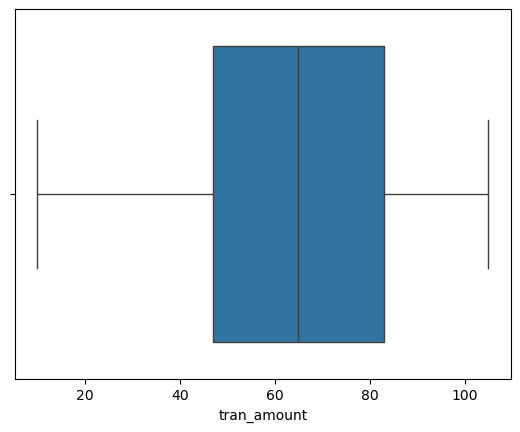

In [139]:
sns.boxplot (x=df['tran_amount'])
plt.show()

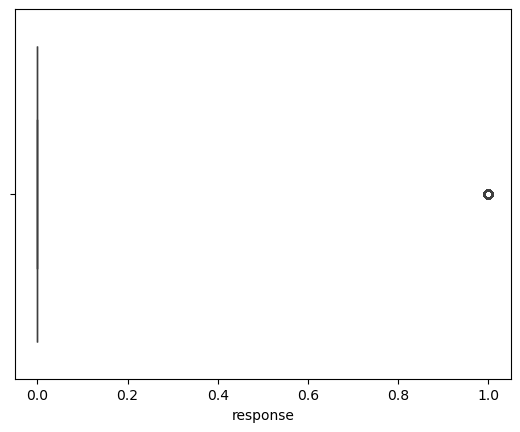

In [140]:
sns.boxplot (x=df['response'])
plt.show()

In [141]:
#creating new columns
df['month']=df['trans_date'].dt.month
df

C:\Users\sajal\AppData\Local\Temp\ipykernel_400\213507561.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['month']=df['trans_date'].dt.month


,customer_id,trans_date,tran_amount,response,month
0,CS5295,2013-02-11,35,1,2
1,CS4768,2015-03-15,39,1,3
2,CS2122,2013-02-26,52,0,2
3,CS1217,2011-11-16,99,0,11
4,CS1850,2013-11-20,78,0,11
...,...,...,...,...,...
124995,CS8433,2011-06-26,64,0,6
124996,CS7232,2014-08-19,38,0,8
124997,CS8731,2014-11-28,42,0,11
124998,CS8133,2013-12-14,13,0,12


In [142]:
# which month had most transaction amount

monthly_sales = df.groupby('month')['tran_amount'].sum()
monthly_sales = monthly_sales.sort_values(ascending=False).reset_index().head(3)
monthly_sales


,month,tran_amount
0,8,726775
1,10,725058
2,1,724089


In [143]:
#counting costomer count

customer_counts =df['customer_id'].value_counts().reset_index()
customer_counts.columns=['customer_id','counts']
customer_counts

#top

top_5_cus=customer_counts.sort_values(by='counts',ascending=False).head(5)
top_5_cus

,customer_id,counts
0,CS4424,39
1,CS4320,38
2,CS3799,36
3,CS3013,35
4,CS1215,35


<Axes: xlabel='customer_id', ylabel='counts'>

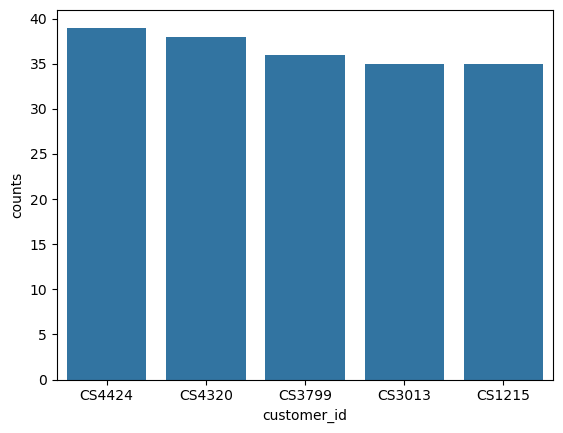

In [144]:
sns.barplot(x='customer_id',y='counts',data=top_5_cus)


In [145]:
#counting costomer sales

customer_sales =df.groupby('customer_id')['tran_amount'].sum().reset_index()
customer_sales

#top

top_5_sal=customer_sales.sort_values(by='tran_amount',ascending=False).head(5)
top_5_sal

,customer_id,tran_amount
3312,CS4424,2933
3208,CS4320,2647
4640,CS5752,2612
3548,CS4660,2527
2687,CS3799,2513


<Axes: xlabel='customer_id', ylabel='tran_amount'>

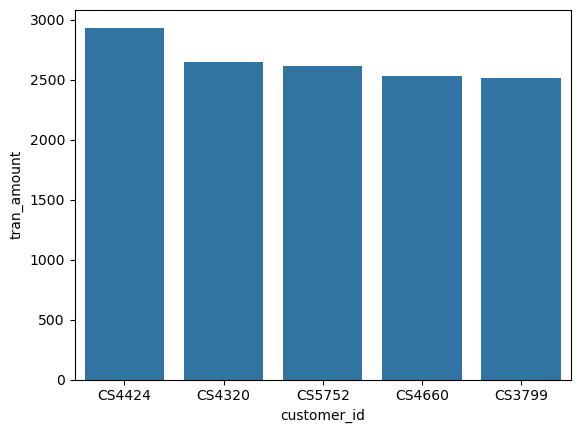

In [146]:
sns.barplot(x='customer_id',y='tran_amount',data=top_5_sal)


In [147]:
import matplotlib.dates as mdate

C:\Users\sajal\AppData\Local\Temp\ipykernel_400\3302878487.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['month_year'] = df['trans_date'].dt.to_period('M')


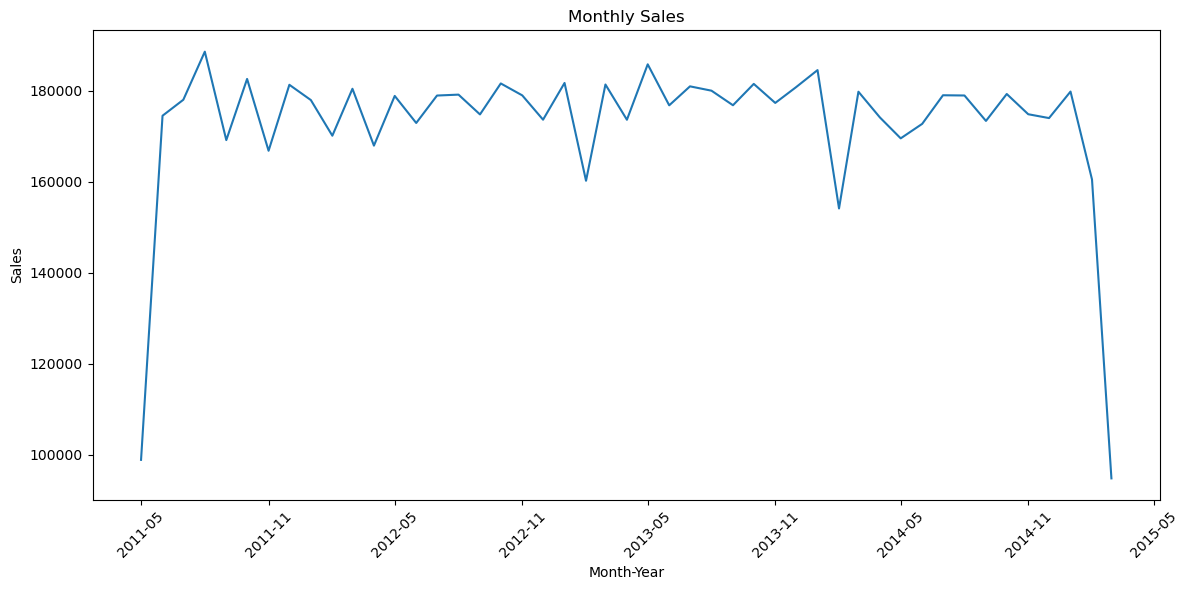

In [148]:
# Convert trans_date to period (Month-Year)
df['month_year'] = df['trans_date'].dt.to_period('M')

# Group by and sum transaction amount
monthly_sales = df.groupby('month_year')['tran_amount'].sum()

# Convert PeriodIndex to Timestamp for plotting
monthly_sales.index = monthly_sales.index.to_timestamp()

# Plotting
plt.figure(figsize=(12, 6))
plt.plot(monthly_sales.index, monthly_sales.values)  # or just plt.plot(monthly_sales)

plt.gca().xaxis.set_major_formatter(mdate.DateFormatter('%Y-%m'))
plt.gca().xaxis.set_major_locator(mdate.MonthLocator(interval=6))

plt.xlabel('Month-Year')
plt.ylabel('Sales')
plt.title('Monthly Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [149]:
### Cohart segmentation

In [150]:
#Recency
recency=df.groupby('customer_id')['trans_date'].max()

#Frequency
frequency=df.groupby('customer_id')['trans_date'].count()

#Monitory
monetory=df.groupby('customer_id')['tran_amount'].sum()

#Combine
rfm=pd.DataFrame({'recency':recency,'frequency':frequency,'monetory':monetory})

In [151]:
rfm

,recency,frequency,monetory
customer_id,,,
CS1112,2015-01-14,15,1012
CS1113,2015-02-09,20,1490
CS1114,2015-02-12,19,1432
CS1115,2015-03-05,22,1659
CS1116,2014-08-25,13,857
...,...,...,...
CS8996,2014-12-09,13,582
CS8997,2014-06-28,14,543
CS8998,2014-12-22,13,624


In [156]:
def segment_customer(row):
    if row['recency'].year >= 2012 and row['frequency'] >= 15 and row['monetory'] > 1000:
        return 'P0'
    elif (2011 <= row['recency'].year < 2012) and (10 < row['frequency'] < 15) and (500 <= row['monetory'] <= 1000):
        return 'P1'
    else:
        return 'P2'

# Apply function to create 'segment' column
rfm['segment'] = rfm.apply(segment_customer, axis=1)


In [157]:
rfm

,recency,frequency,monetory,segment
customer_id,,,,
CS1112,2015-01-14,15,1012,P0
CS1113,2015-02-09,20,1490,P0
CS1114,2015-02-12,19,1432,P0
CS1115,2015-03-05,22,1659,P0
CS1116,2014-08-25,13,857,P2
...,...,...,...,...
CS8996,2014-12-09,13,582,P2
CS8997,2014-06-28,14,543,P2
CS8998,2014-12-22,13,624,P2


<Axes: xlabel='response'>

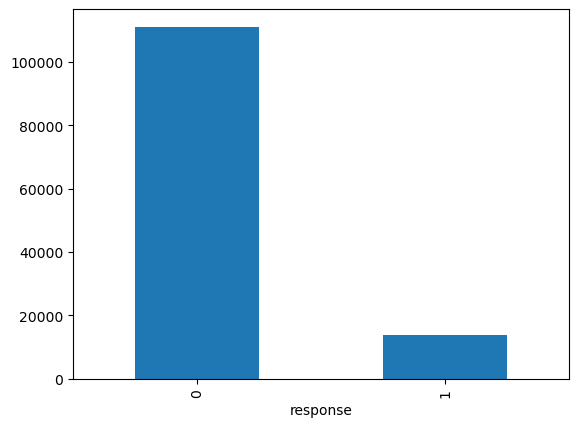

In [158]:
#churn analysis

churn_counts=df['response'].value_counts()

#plot
churn_counts.plot(kind='bar')

<Axes: xlabel='month_year'>

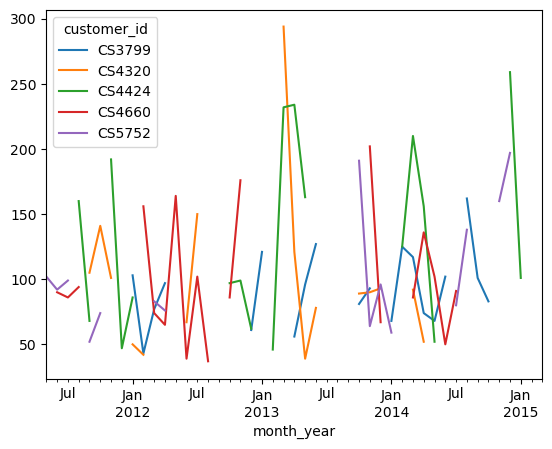

In [159]:
#analysing top customers
top_5_cus=monetory.sort_values(ascending=False).head(5).index

top_customer_df=df[df['customer_id'].isin(top_5_cus)]

top_customer_sales=top_customer_df.groupby(['customer_id','month_year'])['tran_amount'].sum().unstack(level=0)
top_customer_sales.plot(kind='line')

In [165]:
df.to_csv('MainData.csv')

In [166]:
rfm.to_csv('add analysis.csv')